# BASt dataset

**Source**: Bundesanstalt für Straßenwesen, Deutschland  
**Link**: https://www.bast.de/DE/Verkehrstechnik/Fachthemen/v2-verkehrszaehlung/Stundenwerte.html

**Description**:  
Public data from highway traffic counts in Germany for the year 2022. Granularity: number of vehicles per hour.

In [3]:
import pandas as pd

In [4]:
df = pd.read_feather('2022_A_S.feather')
df

,TKNR,Zst,Land,Strklas,Strnum,Datum,Wotag,Fahrtzw,Stunde,KFZ_R1,...,Bus_R2,K_Bus_R2,LoA_R2,K_LoA_R2,Lzg_R2,K_Lzg_R2,Sat_R2,K_Sat_R2,Son_R2,K_Son_R2
0,7016,8001,8,A,5,220101,6,s,1,201,...,-1,x,-1,x,-1,x,-1,x,-1,x
1,7016,8001,8,A,5,220101,6,s,2,450,...,-1,x,-1,x,-1,x,-1,x,-1,x
2,7016,8001,8,A,5,220101,6,s,3,334,...,-1,x,-1,x,-1,x,-1,x,-1,x
3,7016,8001,8,A,5,220101,6,s,4,228,...,-1,x,-1,x,-1,x,-1,x,-1,x
4,7016,8001,8,A,5,220101,6,s,5,157,...,-1,x,-1,x,-1,x,-1,x,-1,x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7603675,5531,4384,16,A,73,221231,6,u,20,49,...,0,-,0,-,0,-,0,-,1,-
7603676,5531,4384,16,A,73,221231,6,u,21,39,...,0,-,0,-,2,-,1,-,0,-
7603677,5531,4384,16,A,73,221231,6,u,22,23,...,0,-,0,-,1,-,0,-,0,-
7603678,5531,4384,16,A,73,221231,6,u,23,29,...,0,-,0,-,2,-,2,-,0,-


In [39]:
df_jawe = pd.read_csv(
    'Jawe2022.csv',
    sep=';',
    encoding='latin1',
    thousands='.',
    decimal=','
)
df_jawe

,TK_Nr,DZ_Nr,DZ_Name,Land_Nr,Land_Code,Str_Kl,Str_Nr,Str_Zus,Erf_Art,Fernziel_Ri1,...,DTV_Bus_Ri1,DTV_LoA_Ri1,DTV_Lzg_Ri1,DTV_Sat_Ri1,DTV_Bus_Ri2,DTV_LoA_Ri2,DTV_Lzg_Ri2,DTV_Sat_Ri2,Anmerkungen,Unnamed: 254
0,4908,5675,AK Leverkusen (O),5,NW,A,1,NaN,8+1,Dortmund,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Datenprobleme in 2022,NaN
1,4908,5035,AK Leverkusen (W),5,NW,A,1,NaN,8+1,Dortmund,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Datenprobleme in 2022,NaN
2,4111,5121,Ascheberg,5,NW,A,1,NaN,8+1,Münster,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Datenprobleme in 2022,NaN
3,5206,5703,Bliesheim,5,NW,A,1,NaN,8+1,Köln,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Baustelle in 2022,NaN
4,5206,5060,Euskirchen/Bliesheim,5,NW,A,1,NaN,8+1,Köln,...,22.0,622.0,2052.0,1721.0,25.0,641.0,2060.0,1752.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,5209,5051,Hennef,5,NW,A,560,NaN,8+1,Altenkirchen (B8),...,32.0,371.0,482.0,359.0,26.0,390.0,498.0,370.0,NaN,NaN
199,5208,5055,AK Bonn Ost (W),5,NW,A,562,NaN,8+1,Kreuz Bonn-Ost (A59),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Datenprobleme in 2022,NaN
200,5208,5626,AK Bonn-Ost (O),5,NW,A,562,NaN,8+1,"Niederholtorf, K8",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Baustelle in 2022,NaN
201,5208,5634,AD Bonn-Beuel (W),5,NW,A,565,NaN,8+1,AD Bonn-Beuel (A59),...,87.0,1345.0,2352.0,1900.0,85.0,1363.0,2240.0,1812.0,NaN,NaN


## Exploration
* Filtere nach Bundesland NRW (Nr. 5)
* Filtere nach am stärksten befahrenen Abschnitt
* Stelle Tagesganglinie für den März dar
    * (nur PKW)

In [ ]:
df_jawe = df_jawe[df_jawe["Land_Nr"] == 5]  # Nur Land Nr. 5 (NRW)

# Der am stärksten befahrene Abschnitt
max_value = df_jawe["DTV_Kfz_MobisSo_Q"].max()
max_row = df_jawe[df_jawe["DTV_Kfz_MobisSo_Q"] == max_value]
print(f"Der am stärksten befahrene Abschnitt: {max_row['DZ_Nr'].values[0]} mit {max_value} Fahrzeugen pro Tag.")
max_row

Der am stärksten befahrene Abschnitt: 5676 mit 171184.0 Fahrzeugen pro Tag.


,TK_Nr,DZ_Nr,DZ_Name,Land_Nr,Land_Code,Str_Kl,Str_Nr,Str_Zus,Erf_Art,Fernziel_Ri1,...,DTV_Bus_Ri1,DTV_LoA_Ri1,DTV_Lzg_Ri1,DTV_Sat_Ri1,DTV_Bus_Ri2,DTV_LoA_Ri2,DTV_Lzg_Ri2,DTV_Sat_Ri2,Anmerkungen,Unnamed: 254
45,4908,5676,AK Leverkusen (S),5,NW,A,3,NaN,8+1,Oberhausen,...,120.0,3148.0,8963.0,7251.0,110.0,3545.0,8855.0,7175.0,NaN,NaN


In [8]:
# Filter für NRW
df = df[df["Land"]==5]
# Filtere nach dem stärksten befahrenen Abschnitt (Herausgefunden aus df_jawe)
df_max = df[df["Zst"] == 5676]
df_max

,TKNR,Zst,Land,Strklas,Strnum,Datum,Wotag,Fahrtzw,Stunde,KFZ_R1,...,Bus_R2,K_Bus_R2,LoA_R2,K_LoA_R2,Lzg_R2,K_Lzg_R2,Sat_R2,K_Sat_R2,Son_R2,K_Son_R2
5387400,4908,5676,5,A,3,220101,6,s,1,798,...,0,s,6,s,13,s,10,s,5,s
5387401,4908,5676,5,A,3,220101,6,s,2,1289,...,0,-,9,-,7,-,7,-,4,-
5387402,4908,5676,5,A,3,220101,6,s,3,1098,...,1,-,4,-,10,-,6,-,9,-
5387403,4908,5676,5,A,3,220101,6,s,4,672,...,0,-,3,-,4,-,4,-,5,-
5387404,4908,5676,5,A,3,220101,6,s,5,492,...,0,-,3,-,10,-,10,-,5,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396155,4908,5676,5,A,3,221231,6,u,20,2147,...,2,s,19,s,24,s,19,s,9,s
5396156,4908,5676,5,A,3,221231,6,u,21,1786,...,1,s,18,s,25,s,20,s,9,s
5396157,4908,5676,5,A,3,221231,6,u,22,1564,...,2,s,11,s,17,s,11,s,6,s
5396158,4908,5676,5,A,3,221231,6,u,23,1377,...,3,s,7,s,16,s,13,s,10,s


In [9]:
# Filtere nach den Spalten, die für die Visualisierung benötigt werden
df_max = df_max[["TKNR", "Zst", "Datum", "Wotag", "Stunde", "KFZ_R1", "KFZ_R2"]]
# Group by Stunde -> Mittelwert pro Stunde
df_max_grouped = df_max.groupby("Stunde").mean().reset_index()
df_max_grouped

,Stunde,TKNR,Zst,Datum,Wotag,KFZ_R1,KFZ_R2
0,1,4908.0,5676.0,220668.323288,4.005479,1149.457534,1118.690411
1,2,4908.0,5676.0,220668.323288,4.005479,894.490411,795.115068
2,3,4908.0,5676.0,220668.323288,4.005479,793.235616,646.027397
3,4,4908.0,5676.0,220668.323288,4.005479,832.109589,704.586301
4,5,4908.0,5676.0,220668.323288,4.005479,1063.194521,1116.843836
5,6,4908.0,5676.0,220668.323288,4.005479,2068.750685,2628.684932
6,7,4908.0,5676.0,220668.323288,4.005479,3465.917808,4259.649315
7,8,4908.0,5676.0,220668.323288,4.005479,4128.383562,4702.043836
8,9,4908.0,5676.0,220668.323288,4.005479,4318.178082,4836.391781
9,10,4908.0,5676.0,220668.323288,4.005479,4456.441096,4740.997260


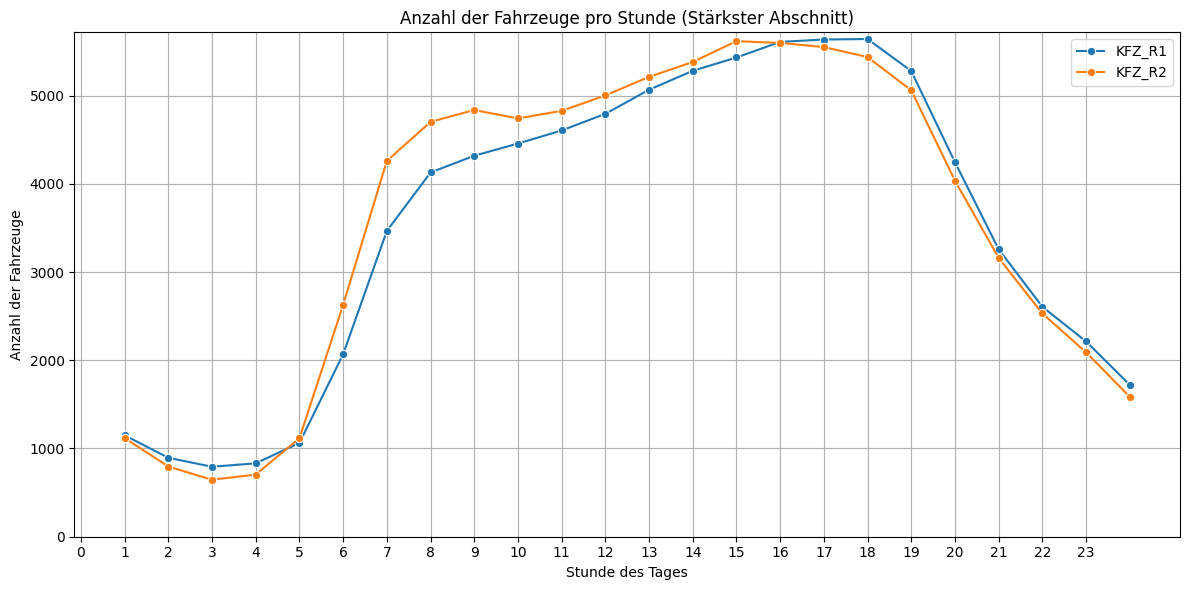

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisierung der Daten
# Linieplot für die Anzahl der Fahrzeuge (KFZ_R1, KFZ_R2) pro Stunde
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_max_grouped, x="Stunde", y="KFZ_R1", label="KFZ_R1", marker='o')
sns.lineplot(data=df_max_grouped, x="Stunde", y="KFZ_R2", label="KFZ_R2", marker='o')
plt.title("Anzahl der Fahrzeuge pro Stunde (Stärkster Abschnitt)")
plt.xlabel("Stunde des Tages")
plt.ylabel("Anzahl der Fahrzeuge")
plt.xticks(range(0, 24))  # Stunden von 0 bis 23
# Y-Achse soll bei 0 beginnen
plt.ylim(0, df_max_grouped["KFZ_R2"].max() + 100)
plt.legend()
plt.grid()
plt.tight_layout()
# plt.savefig("verkehrsaufkommen_staerkster_abschnitt.png")
plt.show()

## Calculate relative traffic (intraday traffic distribution)

In [50]:
def normalize_kfz_columns(df, busiest_day_traffic):
    df.loc[:, 'rel_KFZ_R1'] = df['KFZ_R1'] / busiest_day_traffic
    df.loc[:, 'rel_KFZ_R2'] = df['KFZ_R2'] / busiest_day_traffic
    return df

df_max = normalize_kfz_columns(df_max, max_value)
df_max

,TKNR,Zst,Datum,Wotag,Stunde,KFZ_R1,KFZ_R2,rel_KFZ_R1,rel_KFZ_R2
5387400,4908,5676,220101,6,1,798,1043,0.004662,0.006093
5387401,4908,5676,220101,6,2,1289,1044,0.007530,0.006099
5387402,4908,5676,220101,6,3,1098,1067,0.006414,0.006233
5387403,4908,5676,220101,6,4,672,787,0.003926,0.004597
5387404,4908,5676,220101,6,5,492,680,0.002874,0.003972
...,...,...,...,...,...,...,...,...,...
5396155,4908,5676,221231,6,20,2147,2104,0.012542,0.012291
5396156,4908,5676,221231,6,21,1786,1622,0.010433,0.009475
5396157,4908,5676,221231,6,22,1564,1372,0.009136,0.008015
5396158,4908,5676,221231,6,23,1377,1286,0.008044,0.007512


## Exporting data to json for use in simulation

In [53]:
def df_to_nested_dict(df):
    result = {}

    for _, row in df.iterrows():
        # Datum aufsplitten (Format YYMMDD -> z.B. 220101)
        date_str = str(row['Datum']).zfill(6)
        year = '20' + date_str[:2]
        month = date_str[2:4]
        day = date_str[4:6]
        hour = str(int(row['Stunde'])).zfill(2)  # z. B. 1 -> '01'

        # Dictionarystruktur aufbauen
        result.setdefault(year, {}).setdefault(month, {}).setdefault(day, {})[hour] = float(row['rel_KFZ_R1'])

    return result


In [54]:
result_dict = df_to_nested_dict(df_max)
result_dict["busiest_day_traffic"] = int(max_value)
with open('relatives_verkehrsaufkommen_2022.json', 'w') as f:
    import json
    json.dump(result_dict, f, indent=4, ensure_ascii=False)
result_dict

{'2022': {'01': {'01': {'01': 0.004661650621553416,
    '02': 0.007529909337321245,
    '03': 0.006414150855220114,
    '04': 0.003925600523413403,
    '05': 0.0028741003832133843,
    '06': 0.0024943919992522668,
    '07': 0.002038741938498925,
    '08': 0.001974483596597813,
    '09': 0.002552808673707823,
    '10': 0.004071642209552294,
    '11': 0.007675951023460136,
    '12': 0.01347088512945135,
    '13': 0.01998434433124591,
    '14': 0.025136695018226,
    '15': 0.028349612113281616,
    '16': 0.029301803906907186,
    '17': 0.029307645574352743,
    '18': 0.027631087017478267,
    '19': 0.02301032806804374,
    '20': 0.01901462753528367,
    '21': 0.015684877091316947,
    '22': 0.011490559865407982,
    '23': 0.008855967847462379,
    '24': 0.006472567529675671},
   '02': {'01': 0.005128984017197869,
    '02': 0.0034874754649967285,
    '03': 0.002406766987568932,
    '04': 0.0020153752687167023,
    '05': 0.0022023086269744837,
    '06': 0.0026813253575100476,
    '07': 0.00

In [12]:
import json
import datetime
import random

def json_keys_to_int(x):
    if isinstance(x, dict):
        new_dict = {}
        for key, value in x.items():
            try:
                new_key = int(key)
            except (ValueError, TypeError):
                new_key = key
            new_dict[new_key] = value
        return new_dict
    return x


def random_date(start_year=2022, end_year=2022):
    """
    Generate a random date between Jan 1 of start_year and Dec 31 of end_year.
    """
    start_date = datetime.date(start_year, 1, 1)
    end_date = datetime.date(end_year, 12, 31)
    delta_days = (end_date - start_date).days
    random_days = random.randint(0, delta_days)
    return start_date + datetime.timedelta(days=random_days)

def _construct_depart_time_list_from_distribution( daily_rel_depart_time_distribution_dict, n_vehicles):
    """ 
    Constructs an iterator over a list of departure times from the given dictionary of vehicle distributions over one day. 
    
    Parameters:
        daily_rel_depart_time_distribution_dict (dict): A dictionary mapping the relative amount of vehicles departing to each hour in a day (relative to the max. expected number of vehicles per day). The keys should be in the range [0, 24).
    """
    
    if not daily_rel_depart_time_distribution_dict:
        raise ValueError("When using a custom distribution scenario, depart_time_distribution_dict must be set before generating vehicles.")
    
    depart_time_list = []
    # Add vehicles to the departure time list based on the relative distribution
    for hour, rel_amount in daily_rel_depart_time_distribution_dict.items():

        if rel_amount > 1 or rel_amount < 0:
            raise ValueError(f"Relative amount of vehicles for hour {hour} must be in the range [0, 1]. Found: {rel_amount}")

        amount = round(rel_amount * n_vehicles)
        print(f"Hour {hour}: {amount} vehicles (relative amount: {rel_amount})")
        
        # Set a departure time for each vehicle in this hour
        for _ in range(int(amount)):
            hour_in_seconds = (hour - 1) * 3600
            minutes_in_seconds = random.randint(0, 59) * 60
            depart_time_list.append(hour_in_seconds + minutes_in_seconds)
    return depart_time_list

BAST_DISTRIBUTION_PATH = "relatives_verkehrsaufkommen_2022.json"
n_vehicles = 1000

with open(BAST_DISTRIBUTION_PATH, 'r') as file:
    depart_time_distribution_dict = json.load(file, object_hook=json_keys_to_int)

date = random_date(2022, 2022)
year = (date.year)
month = (date.month)
day = (date.day)
daily_rel_depart_time_distribution_dict = depart_time_distribution_dict[year][month][day]
depart_time_list =  _construct_depart_time_list_from_distribution(daily_rel_depart_time_distribution_dict, n_vehicles)
depart_time_iter = iter(depart_time_list) # initialize an iterator for depart times

Hour 1: 5 vehicles (relative amount: 0.004866108982147864)
Hour 2: 5 vehicles (relative amount: 0.004574025609870081)
Hour 3: 4 vehicles (relative amount: 0.004375408916721189)
Hour 4: 5 vehicles (relative amount: 0.00483105897747453)
Hour 5: 7 vehicles (relative amount: 0.00717356762314235)
Hour 6: 16 vehicles (relative amount: 0.01586596878212917)
Hour 7: 29 vehicles (relative amount: 0.0294186372558183)
Hour 8: 34 vehicles (relative amount: 0.03423217123095616)
Hour 9: 33 vehicles (relative amount: 0.03264323768576503)
Hour 10: 29 vehicles (relative amount: 0.02853070380409384)
Hour 11: 27 vehicles (relative amount: 0.026970978596130478)
Hour 12: 28 vehicles (relative amount: 0.027829703710627162)
Hour 13: 29 vehicles (relative amount: 0.028676745490232733)
Hour 14: 30 vehicles (relative amount: 0.030364987381998318)
Hour 15: 30 vehicles (relative amount: 0.029798345639779417)
Hour 16: 33 vehicles (relative amount: 0.03273670436489391)
Hour 17: 34 vehicles (relative amount: 0.033694

In [13]:
depart_time_list

[2580,
 2040,
 3300,
 960,
 2700,
 6240,
 4860,
 5760,
 4560,
 6660,
 10140,
 10260,
 9180,
 7980,
 12000,
 14160,
 12240,
 14280,
 13140,
 17220,
 17940,
 14700,
 17820,
 17820,
 16440,
 14880,
 18600,
 21060,
 19980,
 19920,
 19200,
 18180,
 19980,
 20100,
 18000,
 19560,
 18660,
 19020,
 18960,
 19920,
 19680,
 19080,
 21720,
 23280,
 24300,
 22860,
 22500,
 23520,
 24540,
 23460,
 21840,
 23700,
 23160,
 24120,
 23580,
 21960,
 23580,
 22260,
 24960,
 22320,
 21720,
 22980,
 22440,
 23340,
 24120,
 21840,
 22380,
 22320,
 22500,
 25140,
 21660,
 27060,
 25740,
 27060,
 27120,
 27120,
 28740,
 28620,
 26280,
 27660,
 26520,
 26820,
 27120,
 28740,
 28020,
 27000,
 26880,
 25620,
 26220,
 27480,
 26040,
 27780,
 28740,
 25380,
 25200,
 28260,
 26040,
 26700,
 28320,
 27840,
 27900,
 28620,
 28680,
 27060,
 28140,
 29040,
 32100,
 30780,
 29820,
 31320,
 31680,
 29700,
 30300,
 28920,
 31980,
 30180,
 31140,
 29400,
 29160,
 28800,
 30540,
 28800,
 32340,
 31680,
 28980,
 29400,
 3108

In [59]:
print(year, month, day)

2022 12 18
